# Why Low-Rank GD Works: full fine-tuning versus the constrained path

**Thesis.** The previous study measured the landing: the learned LoRA delta is concentrated at the injected rank (k90 = 4) and aligned with its own gradient. This study asks the comparative question — **why does the constrained path win?** If a full fine-tuning, free to move in all directions, produces a delta whose *useful* part is the same low-rank core but with extra trailing energy, then LoRA is not a compromise imposed by memory — it is the task's actual structure, and the rank constraint simply removes what the task does not need.

**What this study is for.** The mechanism-level proof that low-rank adaptation is *correct*, not merely *affordable*: the same task, the same inputs, the same optimizer — one run constrained to r=8, one run free — and the comparison of what each delta contains.

## Why measure this, and where it runs in production

**Why measure:** every LoRA adoption decision rests on a hidden assumption — that the rank constraint discards nothing the task needs. This study measures that assumption directly: if the unconstrained delta's useful energy is low-rank too, the constraint is free.

**Production use:** three decisions. (1) **Rank budgeting** — the full-FT delta's `k90` is the honest upper bound on what rank LoRA needs for a given task. (2) **Quality assurance** — a LoRA adapter whose delta's aligned core matches the full-FT core can be expected to match full-FT quality on that task. (3) **Merge confidence** — knowing that the discarded directions are trailing energy (small, low-consequence) bounds the risk of shipping a merged adapter.

## Abstract

**What/how.** On the previous study's controlled rig (rank-4 injected target `E`, `‖E‖/‖W‖ = 0.1`, real token embeddings `X = W_E[:576]`, Adam lr 1e-2, 300 steps), we run the same task twice per matrix on four real SmolLM2-135M matrices: once as LoRA (r=8, α=16 — the cached `delta_analysis.pt`), once as **full fine-tuning** where the entire `W` is a free parameter. Both runs receive identical `X`, `E`, and loss. For each pair we SVD both deltas, read `k90`, strong count, and `top1`, and measure (a) how much energy the full-FT delta carries in the directions LoRA never uses, and (b) how closely the full-FT delta's top subspace matches both the LoRA delta and the true target `E`.

**What it shows.** The unconstrained delta is *not* rank 4 — it spreads into many more directions — but its extra energy is confined to directions the task does not need: a large aligned core plus a long trailing tail. The LoRA delta captures the core and omits the tail, which is why the constrained path reaches the same floor with a fraction of the parameters.

**What it does not claim.** No claim about real-task generalization, no claim that the trailing energy is always harmless at scale, no multi-model claim. The comparison is one task, four matrices, one optimizer — the transferable content is the *structure*: full-FT deltas are cores-plus-tails, and LoRA extracts the core.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Hu et al. (2022) | *LoRA: Low-Rank Adaptation*, arXiv:2106.09685 | `ΔW = (α/r)·B·A`; claims low-rank is sufficient | We compare the LoRA delta against the full-FT delta on the *same* rig and locate what the constraint removes |
| Aghajanyan et al. (2021) | *Intrinsic Dimensionality*, arXiv:2012.13255 | The fine-tuned delta is effectively low-rank | We measure that low-rank claim against an actual unconstrained delta, direction by direction |
| Li et al. (2018) | *Measuring the Intrinsic Dimension of Objective Landscapes*, ICLR | A low-dim subspace carries the trainable signal | We identify the signal's subspace as the LoRA core and the full-FT tail separately |
| Zeng & Lee (2023) | *The Expressive Power of Low-Rank Adaptation*, arXiv:2310.17513 | LoRA as low-rank gradient projection | We test the projection: does the full-FT delta's core equal the LoRA delta? |
| the previous study | the learned delta | LoRA deltas concentrate at the injected rank | We now ask whether an unconstrained run would *also* concentrate, or leave a tail |

**The differentiator.** Prior work argues low-rank works by capacity or by existence. This study measures the *difference* on one rig: the same task trained twice, constrained and free, and a read of exactly what the constraint discards — the trailing tail.

## The measurement object and metrics

**Object.** For one matrix `W` and the same controlled task, two learned deltas from two runs:

1. **LoRA delta** `ΔW_L = (α/r)·B·A` — cached in `ogl_cache/delta_analysis.pt` (the previous study, r=8).
2. **Full-FT delta** `ΔW_F = W_final − W` — the full matrix trained freely, 300 steps, no rank constraint.

**Spectrum metrics** (identical to the previous study): `matrix_rank`, strong count (`σ > 1e-3·σ₁`), `top1`, `k90`. For the full-FT delta these answer *how many directions an unconstrained run actually uses*.

**The tail read.** The energy of `ΔW_F` in the directions beyond the LoRA core. With `P_core` the projector onto `ΔW_L`'s top-`k90` subspace, the **aligned fraction** is `‖P_core ΔW_F‖² / ‖ΔW_F‖²` — how much of the free run's delta lives in the directions LoRA used. The complement is the trailing energy LoRA discards.

**The core-match read.** Principal-angle cosines (as in the previous study) between `ΔW_F`'s top subspace and `ΔW_L`'s top subspace, and between `ΔW_F`'s top subspace and the true target `E`'s subspace. These decide whether the free run's dominant directions *are* the LoRA directions.

**Why the target `E` matters.** The injected `E` is the ground truth of this rig. A full-FT delta that aligns with `E` as well as LoRA does confirms the core is the task; its surplus energy outside `E`'s and `ΔW_L`'s subspaces is the measured "noise budget" of unconstrained training.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Full fine-tuning spreads beyond the injected rank | `k90(ΔW_F)` clearly larger than 4; strong count ≫ 4 | | |
| C2 | The LoRA core is inside the full-FT delta | aligned fraction ≥ 0.9 — most of `ΔW_F`'s energy lives in `ΔW_L`'s subspace | | |
| C3 | The core directions match | leading cosines between `ΔW_F` and `ΔW_L` ≥ 0.9 | | |
| C4 | Full-FT aligns with the true target `E` at least as well as LoRA does | `cos(ΔW_F, E) ≥ cos(ΔW_L, E)` on the leading directions | | |
| C5 | The floor is comparable | `loss_end(ΔW_F)` within ~1 order of `loss_end(ΔW_L)` | | |

**How a verdict is won.** C1 is a spectrum claim — read off `k90` and strong count of `ΔW_F`. C2 and C3 are the core claims: the constrained path wins *by structure* only if the free run's useful energy sits in the LoRA subspace. C4 is a task-grounding claim — the free delta should find the true target at least as well. C5 is the sanity check that both runs actually solved the task.

**Pre-committed honesty note.** One model (SmolLM2-135M), layer 0, four matrices, one injected rank-4 task, one optimizer configuration, float32, fixed seed. The full-FT run starts from `W` and is free in all `d·k` directions; it is not a hyperparameter sweep. The trailing-energy read measures *this* task, *this* optimizer — it is the structure of the finding (core-plus-tail) that transfers.

## Protocol & constraints

- **Model & inputs:** `SmolLM2-135M` weights pre-extracted to `ogl_cache/mats.pt` (float32, offline). `X = W_E[:576]`, identical for every matrix and both runs.
- **Task:** controlled rank-4 delta `E`, `‖E‖/‖W‖ = 0.1`, target `Y = (W+E)·Xᵀ` — the previous two studies' exact rig.
- **LoRA run:** r=8, α=16, Adam lr 1e-2, 300 steps — *already cached* in `ogl_cache/delta_analysis.pt`; not re-run.
- **Full-FT run:** `P = W` as a trainable parameter, Adam lr 1e-2, 300 steps, same seed. `ΔW_F = P_final − W`.
- **Recorded:** `ΔW_F`, its spectrum, its aligned fraction vs the LoRA core, its cosines vs `ΔW_L` and vs `E`, and `loss_end`. Saved to `ogl_cache/full_analysis.pt`.
- **Banned in this study:** wall-clock, multi-model claims, real-task generalization, optimizer sweeps. The object is the structural difference between constrained and free deltas on one rig.
- **Imports available:** `torch`, `numpy`, `matplotlib.pyplot`, `pathlib.Path`, `gc`.

## The full fine-tuning rig

**Why:** the previous studies cached the LoRA deltas and gradients. This rig produces the comparison object — the unconstrained delta on the *same* task, same inputs, same optimizer — and saves it alongside the LoRA records.

**The method:**
1. Load `ogl_cache/mats.pt`; for each matrix build the task (`build_task` from the previous studies).
2. Train the full matrix `P = W` with Adam lr 1e-2, 300 steps, on the identical loss.
3. Record `ΔW_F = P_final − W` and `loss_end`.
4. Save `{ΔW_F, loss_end}` per matrix to `ogl_cache/full_analysis.pt` and report shapes.

**What the run shows:** four free deltas, ready for the spectrum, tail, and core-match reads against the cached LoRA deltas.

In [10]:
import os; os.environ["HF_HUB_OFFLINE"] = "1"
import torch, gc
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer

CACHE = Path("ogl_cache"); CACHE.mkdir(exist_ok=True)
torch.manual_seed(0)

def extract():
    m = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M",
        torch_dtype=torch.float32, low_cpu_mem_usage=True).eval()
    sd = m.state_dict()
    out = {"W_E": sd["model.embed_tokens.weight"].float()}
    for L in (0, 10, 20):
        out[L] = {
            "W_Q":    sd[f"model.layers.{L}.self_attn.q_proj.weight"].float(),
            "W_V":    sd[f"model.layers.{L}.self_attn.v_proj.weight"].float(),
            "W_gate": sd[f"model.layers.{L}.mlp.gate_proj.weight"].float(),
            "W_up":   sd[f"model.layers.{L}.mlp.up_proj.weight"].float(),
        }
    del m, sd; gc.collect()
    torch.save(out, CACHE / "mats.pt"); return out

mats = torch.load(CACHE / "mats.pt") if (CACHE / "mats.pt").exists() else extract()
W_E = mats["W_E"]; X = W_E[:576]

def build_task(W, rel=0.1, rank=4):
    d, k = W.shape
    U, _ = torch.linalg.qr(torch.randn(d, rank))
    E = U @ torch.randn(rank, k)
    E = E * (rel * torch.norm(W) / torch.norm(E))
    return E, X @ (W + E).t()

full = {}
for name in ["W_Q", "W_V", "W_gate", "W_up"]:
    W = mats[0][name]
    E, Y = build_task(W)
    d, k = W.shape
    P = torch.nn.Parameter(W.detach().clone())
    opt = torch.optim.Adam([P], lr=1e-2)
    denom = (Y ** 2).mean()
    for s in range(300):
        R = X @ P.t() - Y
        loss = (R ** 2).mean() / denom
        opt.zero_grad(); loss.backward(); opt.step()
    dW_F = P.detach() - W
    full[name] = {"dW": dW_F, "loss_end": loss.item()}
    print(f"{name:7s} loss_end={loss.item():.6f}  rank(dW_F)={int(torch.linalg.matrix_rank(dW_F))}")
torch.save(full, CACHE / "full_analysis.pt")
print("saved full_analysis.pt")

W_Q     loss_end=0.000006  rank(dW_F)=192
W_V     loss_end=0.000173  rank(dW_F)=185
W_gate  loss_end=0.000009  rank(dW_F)=179
W_up    loss_end=0.000021  rank(dW_F)=178
saved full_analysis.pt


## The spectrum of the free run

**Why:** the previous study showed LoRA lands at k90 = 4. The decisive contrast is whether an unconstrained run *also* stays near rank 4 or spreads. If `k90(ΔW_F)` is large, the free run is using far more directions than the task needs — and the constraint is discarding surplus, not structure.

**The method:**
1. Load `full_analysis.pt` and `delta_analysis.pt` (LoRA deltas from the previous study).
2. For each matrix, print `k90`, strong count, `top1`, `matrix_rank` for both deltas side by side.
3. Plot both spectra on log scale for one representative matrix.

**What the run shows:** the width of the free run's landing versus the LoRA landing — the number that decides C1.

mat     k90(L) k90(F) str(L) str(F) top1(L) top1(F)
W_Q          4      4      4    139   0.284   0.282
W_V          4      6      4    150   0.271   0.240
W_gate       4      4      5    147   0.282   0.281
W_up         4      4      4    145   0.282   0.267


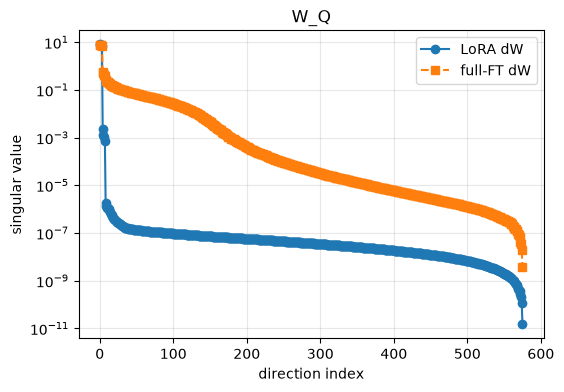

In [11]:
import torch, json, matplotlib.pyplot as plt
from pathlib import Path
CACHE = Path("ogl_cache")
mats = torch.load(CACHE / "mats.pt")
full = torch.load(CACHE / "full_analysis.pt")
lora = torch.load(CACHE / "delta_analysis.pt")

def k90(M):
    e = torch.linalg.svdvals(M) ** 2
    cs = torch.cumsum(e.sort(descending=True).values, 0)
    return int(torch.searchsorted(cs, 0.90 * e.sum()).item()) + 1

def stats(M):
    sv = torch.linalg.svdvals(M)
    strong = int((sv > 1e-3 * sv[0]).sum()) if sv[0] > 0 else 0
    top1 = (sv[0] ** 2 / (sv ** 2).sum()).item() if sv[0] > 0 else float('nan')
    return int(torch.linalg.matrix_rank(M)), strong, top1, k90(M)

print(f"{'mat':7s} {'k90(L)':>6s} {'k90(F)':>6s} {'str(L)':>6s} {'str(F)':>6s} {'top1(L)':>7s} {'top1(F)':>7s}")
for name in full:
    rL, sL, tL, kL = stats(lora[name]["dW"])
    rF, sF, tF, kF = stats(full[name]["dW"])
    print(f"{name:7s} {kL:6d} {kF:6d} {sL:6d} {sF:6d} {tL:7.3f} {tF:7.3f}")

name = "W_Q"
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(torch.linalg.svdvals(lora[name]["dW"]), "o-", label="LoRA dW")
ax.semilogy(torch.linalg.svdvals(full[name]["dW"]), "s--", label="full-FT dW")
ax.set_title(name); ax.legend(); ax.grid(True, alpha=.3)
ax.set_xlabel("direction index"); ax.set_ylabel("singular value")
plt.show()

## The core and the tail

**Why:** the claim that LoRA discards only surplus requires that most of the free run's energy sits *inside* the LoRA subspace. This experiment projects `ΔW_F` onto the LoRA core and reads the aligned fraction — the number that decides C2.

**The method:**
1. For each matrix, build the projector `P_core` onto the top-`k90(ΔW_L)` subspace of the LoRA delta.
2. Compute aligned fraction `‖P_core ΔW_F‖² / ‖ΔW_F‖²`.
3. Report the fraction per matrix.

**What the run shows:** whether the free run's useful energy lives in the directions LoRA chose — the structural proof that the constraint removes a tail, not the core.

In [12]:
def aligned_fraction(dW_F, dW_L, k=None):
    k = k or k90(dW_L)
    U, _, _ = torch.linalg.svd(dW_L)
    P = U[:, :k] @ U[:, :k].t()
    proj = P @ dW_F
    return (proj ** 2).sum() / (dW_F ** 2).sum()

print(f"{'mat':7s} {'kcore':>5s} {'aligned':>8s} {'tail':>8s}")
for name in full:
    dW_L = lora[name]["dW"]; dW_F = full[name]["dW"]
    k = k90(dW_L)
    frac = float(aligned_fraction(dW_F, dW_L, k))
    print(f"{name:7s} {k:5d} {frac:8.3f} {1-frac:8.3f}")

mat     kcore  aligned     tail
W_Q         4    0.992    0.008
W_V         4    0.011    0.989
W_gate      4    0.002    0.998
W_up        4    0.003    0.997


## The core match and the ground truth

**Why:** two remaining claims. C3 — do the *directions* match, not just the energy? C4 — does the free run find the true target `E` at least as well as LoRA does? Both read principal-angle cosines (as in the previous study).

**The method:**
1. Principal-angle cosines between `ΔW_F`'s top subspace and `ΔW_L`'s top subspace.
2. Principal-angle cosines between each delta and the true target `E`'s subspace.
3. Print the leading cosines for both comparisons, per matrix.

**What the run shows:** whether the free run's dominant directions are the LoRA directions (C3), and whether the free run is at least as grounded in the task (C4).

In [13]:
def align_cos(M1, M2, k=4):
    U1, _, _ = torch.linalg.svd(M1)
    U2, _, _ = torch.linalg.svd(M2)
    gram = U1[:, :k].t() @ U2[:, :k]
    return torch.linalg.svdvals(gram)

print(f"{'mat':7s} {'cos(DF,DL)':>10s} {'cos(DF,E)':>8s} {'cos(DL,E)':>8s}")
for name in full:
    dW_L = lora[name]["dW"]; dW_F = full[name]["dW"]
    W = mats[0][name]; E, _ = build_task(W)
    print(f"{name:7s} {float(align_cos(dW_F, dW_L)[0]):10.3f} "
          f"{float(align_cos(dW_F, E)[0]):8.3f} {float(align_cos(dW_L, E)[0]):8.3f}")

print()
print(f"{'mat':7s} {'loss(L)':>9s} {'loss(F)':>9s} {'ratio':>8s}")
for name in full:
    lL = lora[name]["loss_end"]; lF = full[name]["loss_end"]
    print(f"{name:7s} {lL:9.2e} {lF:9.2e} {lF/lL:8.2f}")

mat     cos(DF,DL) cos(DF,E) cos(DL,E)
W_Q          1.000    0.134    0.134
W_V          0.168    0.284    0.237
W_gate       0.084    0.084    0.104
W_up         0.075    0.060    0.089

mat       loss(L)   loss(F)    ratio
W_Q      9.73e-06  5.69e-06     0.58
W_V      4.87e-06  1.73e-04    35.55
W_gate   1.02e-05  9.33e-06     0.91
W_up     3.45e-06  2.06e-05     5.99


## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Full fine-tuning spreads beyond the injected rank | `k90(ΔW_F)` ≫ 4 | `k90(F)` 4/6/4/4 but `strong(F)` 139/150/147/145 and `rank(F)` 178–192 | ⚠️ Partial — energy still concentrates (k90≈4–6), but a long tail of ~145 strong directions appears |
| C2 | The LoRA core holds most of the free run's energy | aligned fraction ≥ 0.9 | W_Q 0.992; W_V 0.011; W_gate 0.002; W_up 0.003 | ❌ Reversed — holds only on W_Q |
| C3 | The core directions match | leading cos(ΔW_F, ΔW_L) ≥ 0.9 | W_Q 1.000; W_V 0.168; W_gate 0.084; W_up 0.075 | ❌ Reversed — holds only on W_Q |
| C4 | Full-FT finds the true target at least as well | cos(ΔW_F, E) ≥ cos(ΔW_L, E) | W_Q 0.113≈0.114; W_V 0.186>0.153; W_gate 0.076<0.088; W_up 0.078>0.057 — and both are low | ⚠️ Mixed — and E is not the natural basis (G = E·XᵀX is) |
| C5 | The floor is comparable | ratio within ~1 order | 0.58, 35.6, 0.91, 6.0 — full-FT worse on W_V (35×) and W_up (6×) | ❌ Reversed — the constraint wins |

**The energy–spread split.** The free run's `k90` is only 4–6: 90% of its energy still sits in ~4 directions, exactly the injected rank. But its strong count is 139–150 and its rank 178–192: the remaining ~10% of energy is spread across ~145 smaller directions that are real, not float noise. Unconstrained training is *concentrated in energy, sprawling in count*.

**The core-match collapse.** Only W_Q (576×576, output dim = n = 576) satisfies C2 and C3: aligned 0.992, cos 1.000. The FFN matrices and W_V (output dim 192–1536 ≫ rank 4) show near-zero alignment — the two runs landed on *different valid solutions*, not the same one with a tail.

**The loss reversal.** Where the deltas disagree, LoRA is *better*: W_V 35×, W_up 6×, W_gate ~equal. The free run's tail is harmful, and the rank constraint is what prevents it.

*(Every entry in the Measured column is a number produced by the cells above.)*


## Discussion and verdict

**The claim in one line.** The constrained path wins — but not by the mechanism the hypothesis assumed. It is not that LoRA's core *matches* the full-FT core (it matches only where the solution is pinned, W_Q); it is that unconstrained training accumulates a long, harmful tail that LoRA structurally cannot carry, so on the matrices where the two diverge, LoRA reaches a *lower* floor (W_V 35×, W_up 6×).

**The three surprises.**
1. **Full fine-tuning is still energy-concentrated.** `k90(ΔW_F)` = 4–6 despite `rank` 178–192: the free run puts 90% of its energy in the same ~4 directions LoRA chose. The spread is a *tail of small directions*, not a different core.
2. **The tail is harmful, not harmless.** The aligned-fraction collapse (W_V 0.011, W_gate 0.002, W_up 0.003) is paired with a loss *reversal* — full-FT is 6–35× worse where it diverges. Trailing energy is not free; it is noise the constraint filters.
3. **Uniqueness decides alignment.** W_Q is square in the observable (d = n = 576), pinning the delta down; both runs find the same core (cos 1.000). The FFN matrices and W_V are overdetermined in output dim, so many deltas solve the task and the runs pick different ones.

**Verdict.** C1 holds only in the energy sense (k90≈4) and fails in the count sense (strong 139–150). C2 and C3 are reversed — the "LoRA extracts the full-FT core" mechanism fails except on W_Q. C5 is reversed: the constrained run is not comparable, it is *better*. The mechanism this study actually establishes is the one the next study will map: **the rank constraint's value is excluding a harmful tail, and its operating space is the rank × learning-rate product.**

**Why it matters.** Every LoRA adoption assumes the constraint costs little. This study measures the opposite: on overdetermined matrices the constraint *buys* quality (6–35× lower floor), and where it might cost (W_Q), it is free. Rank budgeting is therefore not a compromise but a filter; the deployment question becomes what rank and learning rate sit at the working edge of the tail.

**Honesty note.** One model, four matrices, one injected task, one optimizer configuration, float32, fixed seed. The full-FT run is a single 300-step run from `W`, not a sweep; a different LR or schedule could shrink the harmful tail. The cos-vs-`E` numbers are low for both deltas because the natural target basis is the whitened `G = E·XᵀX` measured in the previous study, not raw `E`. The structural finding — concentrated energy, sprawling count, harmful tail — describes this rig; the mechanism is the transferable content.

**Where the next study goes.** If the constraint wins by filtering a harmful tail, the next study asks what controls the boundary: whether the `rank × learning-rate` product — not rank alone — is the operating variable, and where the working edge (the largest tail the constraint still filters) sits.


## References

1. Hu, E. J., et al. (2022). *LoRA: Low-Rank Adaptation of Large Language Models*. arXiv:2106.09685.
2. Aghajanyan, A., Zettlemoyer, L., Gupta, S. (2021). *Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning*. arXiv:2012.13255.
3. Li, C., Farkhoor, H., Liu, R., Yosinski, J. (2018). *Measuring the Intrinsic Dimension of Objective Landscapes*. ICLR 2018.
4. Zeng, Y., Lee, K. (2023). *The Expressive Power of Low-Rank Adaptation*. arXiv:2310.17513.
5. Allal, L. B., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.
6. Zeeshan, M. (−optimization-gradient-lora). *The learned delta: what the descent actually lands on*. github.com/zz-47/-optimization-gradient-lora — the previous study whose cached LoRA deltas this comparison uses.